<a href="https://colab.research.google.com/github/risyadksm/PCVK_GANJIL_2025/blob/main/TUGAS_S2MRTI_WEEK6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Muh. Nur Risyad Rais Rafsanjani Hadi Kusuma
# NIM : 245107080001

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from google.colab import files
from google.colab.patches import cv2_imshow
from skimage import filters, io, img_as_float
from io import BytesIO
from scipy.ndimage import convolve

# SOAL NO 1

Saving ctscan_head.jpg to ctscan_head (2).jpg
File terupload: ctscan_head (2).jpg


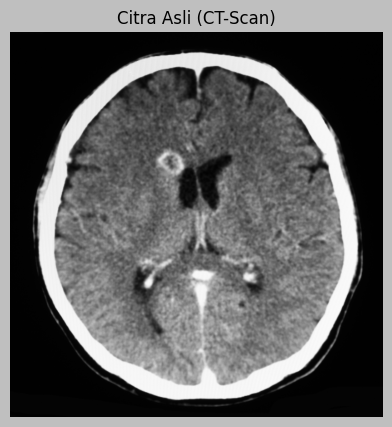

In [ ]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("File terupload:", filename)

img_orig = cv2.imread(filename, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

plt.figure(figsize=(5,5))
plt.imshow(img_orig, cmap='gray')
plt.title("Citra Asli (CT-Scan)")
plt.axis('off')
plt.show()


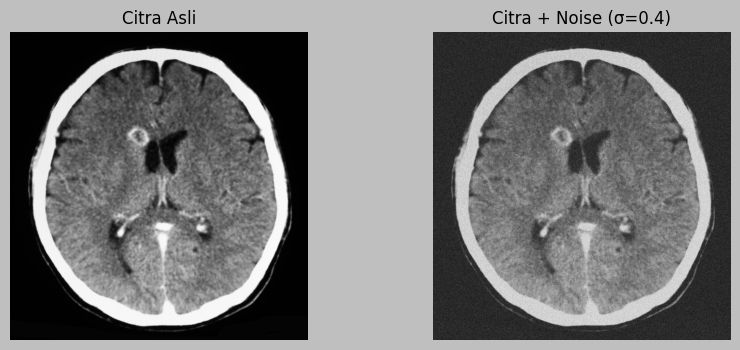

In [ ]:
# === Tambah noise Gaussian ke citra / untuk mencoba citra non-noise ===

noise_sigma = 0.4  # standar deviasi noise
noise = np.random.normal(0, noise_sigma, img_orig.shape)
img_noisy = np.clip(img_orig + noise, 0, 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_orig, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_noisy, cmap='gray')
plt.title(f"Citra + Noise (σ={noise_sigma})")
plt.axis('off')
plt.show()


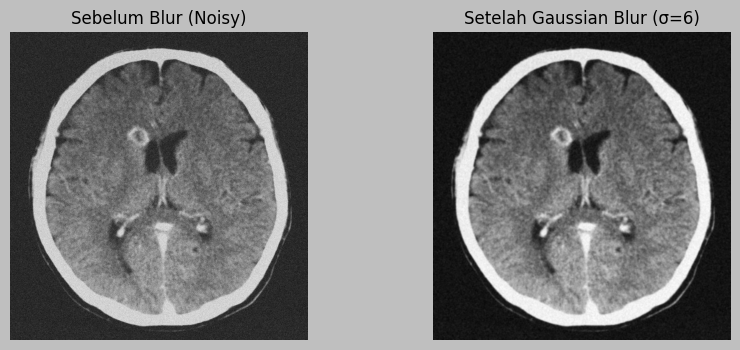

In [ ]:
# === Reduksi noise menggunakan Gaussian Blur ===

sigma_blur = 6  # nilai sigma untuk Gaussian
k = int(2 * round(3 * sigma_blur) + 1)

img_blur = cv2.GaussianBlur(img_noisy, (k, k), sigmaX=sigma_blur, sigmaY=sigma_blur)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_noisy, cmap='gray')
plt.title("Sebelum Blur (Noisy)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_blur, cmap='gray')
plt.title(f"Setelah Gaussian Blur (σ={sigma_blur})")
plt.axis('off')
plt.show()


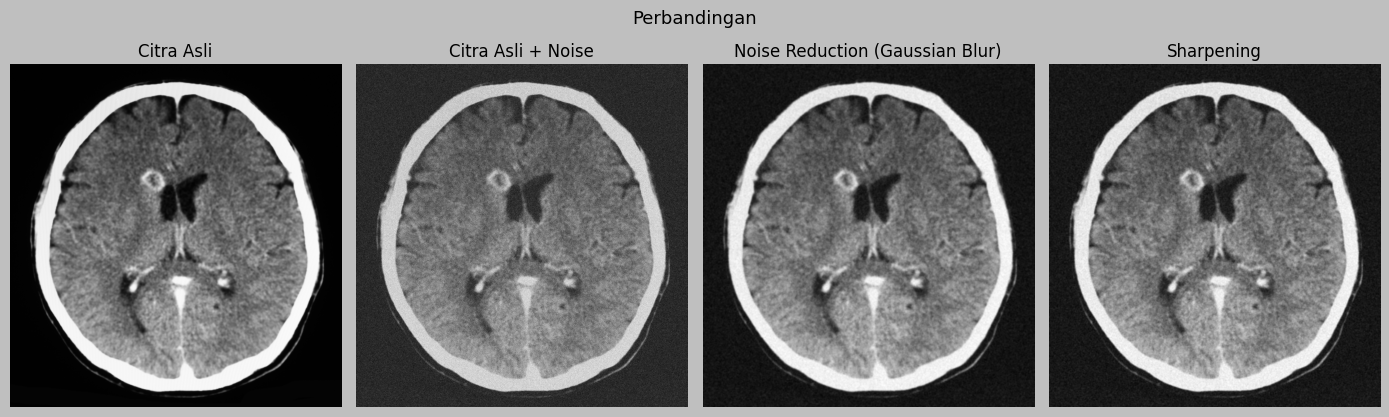

In [ ]:
# === Penajaman citra menggunakan Unsharp Masking ===

alpha = 5  # sharpening

blur_for_sharp = cv2.GaussianBlur(img_blur, (k, k), sigmaX=sigma_blur)
mask = img_blur - blur_for_sharp
img_sharp = np.clip(img_blur + alpha * mask, 0, 1)

plt.figure(figsize=(14,5))

plt.subplot(1,4,1)
plt.imshow(img_orig, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(img_noisy, cmap='gray')
plt.title("Citra Asli + Noise")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img_blur, cmap='gray')
plt.title("Noise Reduction (Gaussian Blur)")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(img_sharp, cmap='gray')
plt.title("Sharpening")
plt.axis('off')

plt.suptitle("Perbandingan", fontsize=13, y=0.92)
plt.tight_layout()
plt.show()


In [ ]:
# Fungsi bantu: MSE dan PSNR
def mse(a, b):
    return np.mean((a - b) ** 2)

def psnr(a, b):
    mse_val = mse(a, b)
    if mse_val == 0:
        return float('inf')
    return 10 * math.log10(1.0 / mse_val)

# Fungsi bantu: menghitung rasio pelestarian tepi
def edge_preservation_ratio(original, processed):
    orig_u8 = (np.clip(original,0,1)*255).astype(np.uint8)
    proc_u8 = (np.clip(processed,0,1)*255).astype(np.uint8)
    med = np.median(orig_u8)
    t1 = int(max(10, 0.66 * med))
    t2 = int(min(200, 1.33 * med))
    edges_orig = cv2.Canny(orig_u8, t1, t2)
    edges_proc = cv2.Canny(proc_u8, t1, t2)
    orig_count = np.count_nonzero(edges_orig)
    if orig_count == 0:
        return 0.0
    inter = np.count_nonzero(cv2.bitwise_and(edges_orig, edges_proc))
    return inter / orig_count


In [ ]:
# === Evaluasi Kualitas Citra ===
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# Karena citra float (0–1), tambahkan data_range=1.0 pada PSNR & SSIM
mse_noisy = mean_squared_error(img_orig, img_noisy)
psnr_noisy = peak_signal_noise_ratio(img_orig, img_noisy, data_range=1.0)
ssim_noisy = structural_similarity(img_orig, img_noisy, data_range=1.0)

mse_blur = mean_squared_error(img_orig, img_blur)
psnr_blur = peak_signal_noise_ratio(img_orig, img_blur, data_range=1.0)
ssim_blur = structural_similarity(img_orig, img_blur, data_range=1.0)

mse_sharp = mean_squared_error(img_orig, img_sharp)
psnr_sharp = peak_signal_noise_ratio(img_orig, img_sharp, data_range=1.0)
ssim_sharp = structural_similarity(img_orig, img_sharp, data_range=1.0)

# Cetak hasil
print("=== Evaluasi Kualitas Citra (dengan data_range=1.0) ===")
print(f"Noise     -> MSE: {mse_noisy:.5f}, PSNR: {psnr_noisy:.2f} dB, SSIM: {ssim_noisy:.4f}")
print(f"Blur      -> MSE: {mse_blur:.5f}, PSNR: {psnr_blur:.2f} dB, SSIM: {ssim_blur:.4f}")
print(f"Sharpened -> MSE: {mse_sharp:.5f}, PSNR: {psnr_sharp:.2f} dB, SSIM: {ssim_sharp:.4f}")


=== Evaluasi Kualitas Citra (dengan data_range=1.0) ===
Noise     -> MSE: 0.08839, PSNR: 10.54 dB, SSIM: 0.1236
Blur      -> MSE: 0.02209, PSNR: 16.56 dB, SSIM: 0.1206
Sharpened -> MSE: 0.02199, PSNR: 16.58 dB, SSIM: 0.1187


# SOAL NO 2

In [ ]:
uploaded = files.upload()

Saving A.jpg to A.jpg
Saving B.png to B.png


Saving A.jpg to A (3).jpg
Saving B.png to B (3).png


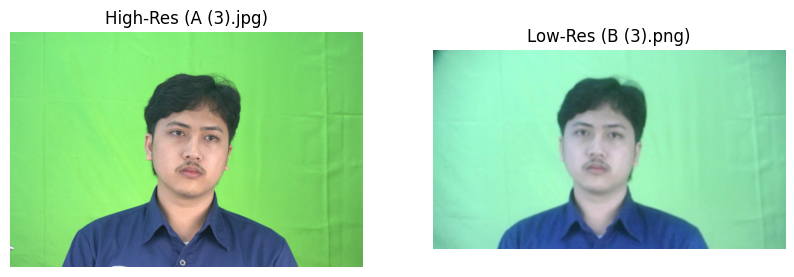

In [ ]:
uploaded = files.upload()

# Cek jumlah file
if len(uploaded) < 2:
    print("⚠️ Upload minimal 2 citra (High-Res dan Low-Res).")
else:
    # Ambil nama file
    filenames = list(uploaded.keys())

    # Baca citra grayscale
    img_high = img_as_float(io.imread(BytesIO(uploaded[filenames[0]]), as_gray=False))
    img_low = img_as_float(io.imread(BytesIO(uploaded[filenames[1]]), as_gray=False))

    # Visualisasi citra
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(img_high, cmap='gray')
    axes[0].set_title(f'High-Res ({filenames[0]})')
    axes[0].axis('off')

    axes[1].imshow(img_low, cmap='gray')
    axes[1].set_title(f'Low-Res ({filenames[1]})')
    axes[1].axis('off')
    plt.show()

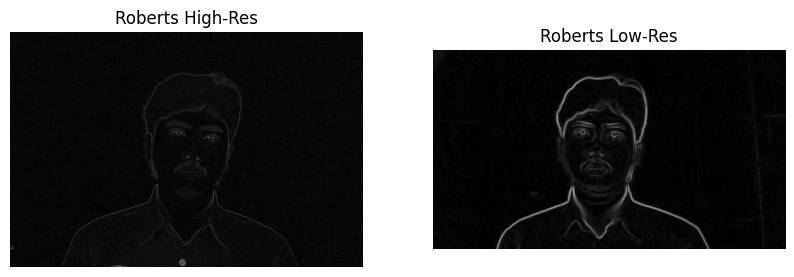

In [ ]:
# Roberts operator
edges_roberts_high = filters.roberts(img_high)
edges_roberts_low = filters.roberts(img_low)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(edges_roberts_high, cmap='gray')
axes[0].set_title('Roberts High-Res')
axes[0].axis('off')

axes[1].imshow(edges_roberts_low, cmap='gray')
axes[1].set_title('Roberts Low-Res')
axes[1].axis('off')
plt.show()


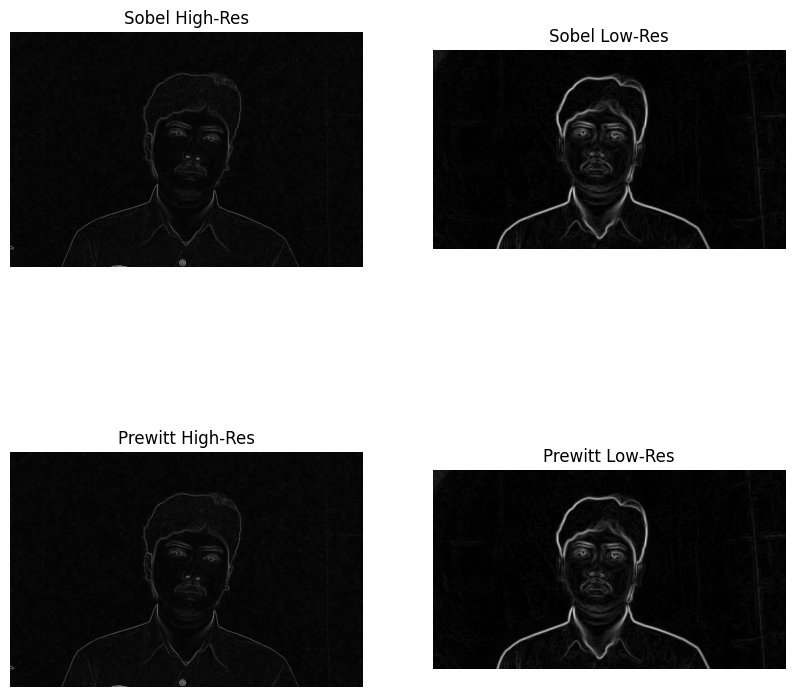

In [ ]:
# Sobel
edges_sobel_high = filters.sobel(img_high)
edges_sobel_low = filters.sobel(img_low)

# Prewitt
edges_prewitt_high = filters.prewitt(img_high)
edges_prewitt_low = filters.prewitt(img_low)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(edges_sobel_high, cmap='gray')
axes[0,0].set_title('Sobel High-Res')
axes[0,0].axis('off')

axes[0,1].imshow(edges_sobel_low, cmap='gray')
axes[0,1].set_title('Sobel Low-Res')
axes[0,1].axis('off')

axes[1,0].imshow(edges_prewitt_high, cmap='gray')
axes[1,0].set_title('Prewitt High-Res')
axes[1,0].axis('off')

axes[1,1].imshow(edges_prewitt_low, cmap='gray')
axes[1,1].set_title('Prewitt Low-Res')
axes[1,1].axis('off')

plt.show()


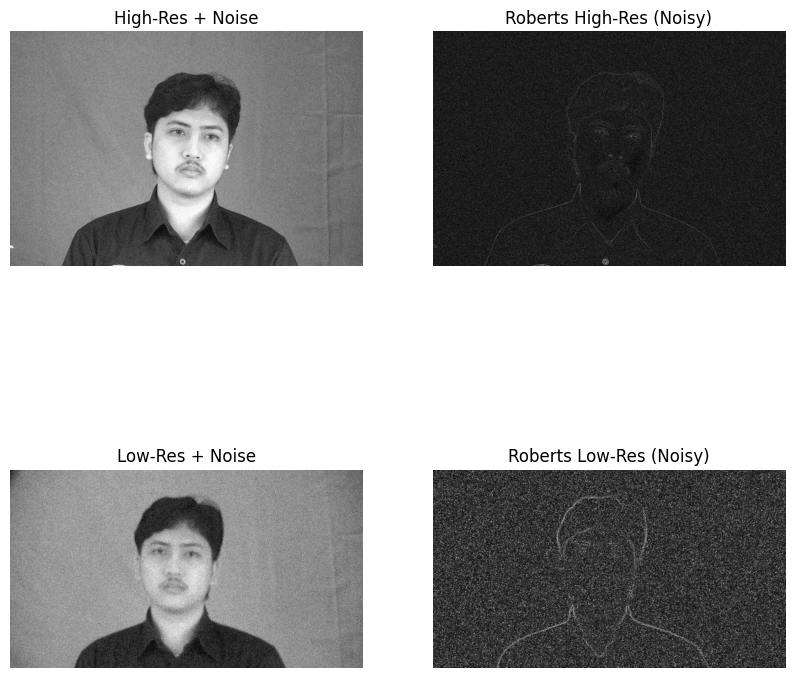

In [ ]:
# Tambahkan Gaussian noise
noisy_high = img_high + 0.05 * np.random.randn(*img_high.shape)
noisy_low = img_low + 0.05 * np.random.randn(*img_low.shape)
noisy_high = np.clip(noisy_high, 0, 1)
noisy_low = np.clip(noisy_low, 0, 1)

# Roberts pada citra noisy
edges_roberts_high_noisy = filters.roberts(noisy_high)
edges_roberts_low_noisy = filters.roberts(noisy_low)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(noisy_high, cmap='gray')
axes[0,0].set_title('High-Res + Noise')
axes[0,0].axis('off')

axes[0,1].imshow(edges_roberts_high_noisy, cmap='gray')
axes[0,1].set_title('Roberts High-Res (Noisy)')
axes[0,1].axis('off')

axes[1,0].imshow(noisy_low, cmap='gray')
axes[1,0].set_title('Low-Res + Noise')
axes[1,0].axis('off')

axes[1,1].imshow(edges_roberts_low_noisy, cmap='gray')
axes[1,1].set_title('Roberts Low-Res (Noisy)')
axes[1,1].axis('off')

plt.show()


In [ ]:
# Fungsi metrik sederhana
def edge_metric(edge):
    return np.std(edge)

metrics = {
    'Roberts_High': edge_metric(edges_roberts_high),
    'Roberts_Low': edge_metric(edges_roberts_low),
    'Sobel_High': edge_metric(edges_sobel_high),
    'Sobel_Low': edge_metric(edges_sobel_low),
    'Prewitt_High': edge_metric(edges_prewitt_high),
    'Prewitt_Low': edge_metric(edges_prewitt_low),
}

print("Nilai Standar Deviasi (Semakin tinggi, tepi lebih tajam):")
for k, v in metrics.items():
    print(f"{k:15s} : {v:.4f}")


Nilai Standar Deviasi (Semakin tinggi, tepi lebih tajam):
Roberts_High    : 0.0177
Roberts_Low     : 0.0142
Sobel_High      : 0.0180
Sobel_Low       : 0.0187
Prewitt_High    : 0.0176
Prewitt_Low     : 0.0186


# SOAL NO 3

Saving human2.jpg to human2 (2).jpg


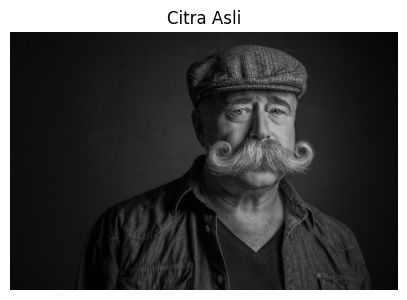

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# === 2. Baca citra dalam grayscale ===
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Visualisasi citra asli
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')
plt.show()

In [ ]:
# === Definisikan kernel 3x3 (misal Sobel horizontal untuk deteksi tepi) ===
kernel = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])

# === Konvolusi dengan tiga metode penanganan tepi ===
conv_zero = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_CONSTANT) # (a) Padding nol
conv_replicate = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_REPLICATE) # (b) Duplikasi piksel tepi
conv_reflect = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_REFLECT) # (c) Refleksi citra

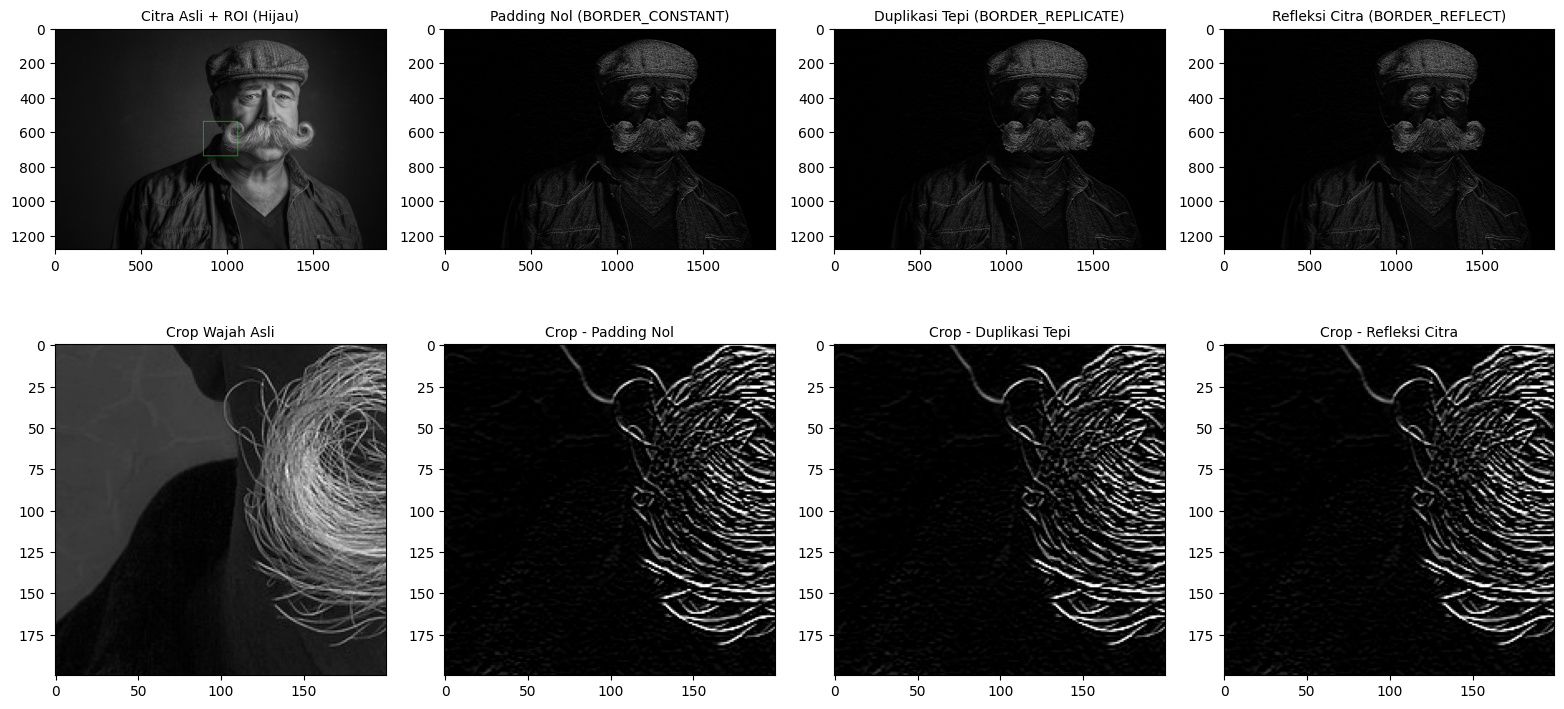

In [ ]:
roi_size = 200
cx, cy = w // 2, h // 2
x1, y1 = cx - roi_size // 2, cy - roi_size // 2
x2, y2 = cx + roi_size // 2, cy + roi_size // 2

# Pastikan tetap di dalam batas
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(w, x2), min(h, y2)

# === 6. Tambahkan kotak ROI di citra asli ===
img_box = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.rectangle(img_box, (x1, y1), (x2, y2), (0,255,0), 2)

# === 7. Crop area ROI pada masing-masing hasil ===
crop_asli = img[y1:y2, x1:x2]
crop_zero = conv_zero[y1:y2, x1:x2]
crop_replicate = conv_replicate[y1:y2, x1:x2]
crop_reflect = conv_reflect[y1:y2, x1:x2]

# === 8. Tampilkan hasil dalam 2 baris ===
plt.figure(figsize=(16,8))

titles_top = [
    "Citra Asli + ROI (Hijau)",
    "Padding Nol (BORDER_CONSTANT)",
    "Duplikasi Tepi (BORDER_REPLICATE)",
    "Refleksi Citra (BORDER_REFLECT)"
]

images_top = [cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB),
              conv_zero, conv_replicate, conv_reflect]

titles_bottom = [
    "Crop Wajah Asli",
    "Crop - Padding Nol",
    "Crop - Duplikasi Tepi",
    "Crop - Refleksi Citra"
]

images_bottom = [crop_asli, crop_zero, crop_replicate, crop_reflect]

# Baris atas
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(images_top[i], cmap='gray')
    plt.title(titles_top[i], fontsize=10)
    plt.axis('on')

# Baris bawah (hasil crop)
for i in range(4):
    plt.subplot(2, 4, i+5)
    plt.imshow(images_bottom[i], cmap='gray')
    plt.title(titles_bottom[i], fontsize=10)
    plt.axis('on')

plt.tight_layout(pad=2.0, w_pad=1.0)
plt.show()